# **El juego de la vida de Conway**

En este Notebook te explicaremos un poco acerca de cómo funciona el juego de la vida de Conway, este es un algoritmo bastante interesante que aprovecha el modelo de un autómata celular para hacer una simulación bastante simple de la "vida", para esto se usa una serie de reglas que explicaremos a continuación.

Pero...

#**¿Qué es un autómata celular?**

Un autómata celular es un modelo computacional que funciona a partir de una cuadrícula en la cual cada celda funciona como una "celula" en el sentido de que puede estar "viva" o "muerta", es decir, cada celda puede encontrarse en un número finito de estados. En la siguiente imagen podemos observar un autómata celular en el cual su celda central se encuentra en el estado "azul", las celdas a su alrededor se encuentran en el estado "rojo" y las celdas exteriores se encuentran en el estado "blanco".

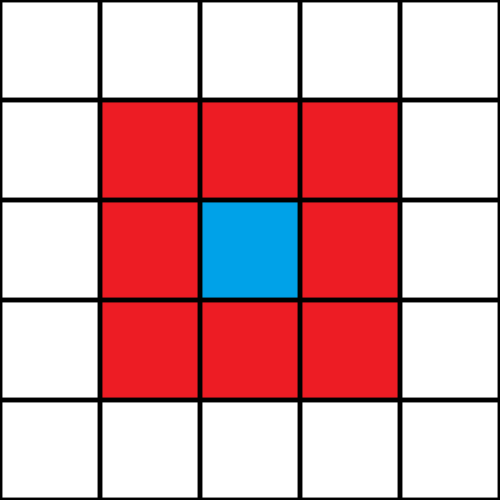

Los autómatas celulares funcionan de manera iterativa, esto es, en un momento inicial tu le das una información inicial, esta información serán los estados en los que se encuentran las celdas inicialmente, y posteriormente el programa calculará el estado para los siguientes momentos a partir de la información del momento anterior. Es decir, si a un autómata celular tu le das como entrada la información anterior, es posible que en el siguiente momento obtengas algo similar a esto:

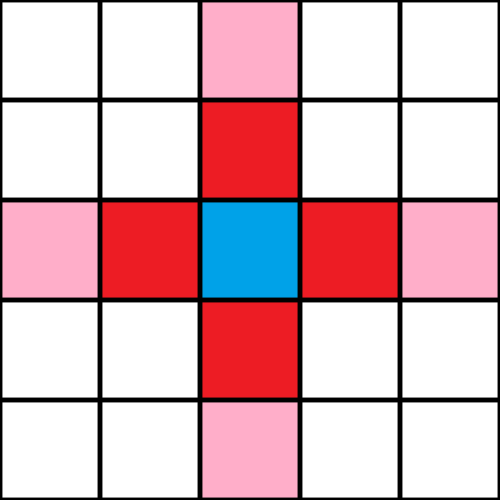

# **Código**

A continuación veremos una implementación del juego de la vida a través de un programa realizado en el lenguaje [Python](https://es.wikipedia.org/wiki/Python)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display
import ipywidgets as widgets

# ── Parámetros ────────────────────────────────────────────────────
FILAS      = 80
COLUMNAS   = 80
COLOR_MAPA = 'Greens'
GIF_PATH   = 'vida.gif'

# ── Funciones del juego ───────────────────────────────────────────
def siguiente_generacion(tablero):
    vecinas = sum([
        np.roll(tablero, s, axis=a)
        for s in (1,-1) for a in (0,1)
    ] + [
        np.roll(np.roll(tablero, dr, axis=0), dc, axis=1)
        for dr in (1,-1) for dc in (1,-1)
    ])
    nuevo = np.zeros_like(tablero)
    nuevo[(tablero==1) & ((vecinas==2)|(vecinas==3))] = 1
    nuevo[(tablero==0) & (vecinas==3)] = 1
    return nuevo

def tablero_vacio():
    return np.zeros((FILAS, COLUMNAS), dtype=int)

def poner(t, r, c, celulas):
    """Coloca una lista de (dr,dc) relativo a (r,c)."""
    for dr, dc in celulas:
        rr, cc = r+dr, c+dc
        if 0 <= rr < FILAS and 0 <= cc < COLUMNAS:
            t[rr, cc] = 1

# ── Patrones ──────────────────────────────────────────────────────

def patron_glider():
    t = tablero_vacio()
    poner(t, 2, 2, [(0,1),(1,2),(2,0),(2,1),(2,2)])
    return t

def patron_blinker():
    t = tablero_vacio()
    r, c = FILAS//2, COLUMNAS//2
    poner(t, r, c, [(0,-1),(0,0),(0,1)])
    return t

def patron_pulsar():
    t = tablero_vacio()
    r, c = FILAS//2, COLUMNAS//2
    coords = [
        (-6,-4),(-6,-3),(-6,-2),(-6,2),(-6,3),(-6,4),
        (-4,-6),(-3,-6),(-2,-6),(-4,6),(-3,6),(-2,6),
        (-4,-1),(-3,-1),(-2,-1),(-4,1),(-3,1),(-2,1),
        (-1,-4),(-1,-3),(-1,-2),(-1,2),(-1,3),(-1,4),
        (1,-4),(1,-3),(1,-2),(1,2),(1,3),(1,4),
        (2,-6),(3,-6),(4,-6),(2,6),(3,6),(4,6),
        (2,-1),(3,-1),(4,-1),(2,1),(3,1),(4,1),
        (6,-4),(6,-3),(6,-2),(6,2),(6,3),(6,4),
    ]
    poner(t, r, c, coords)
    return t

def patron_gosper_gun():
    """Gosper Glider Gun — dispara un glider cada 30 generaciones."""
    t = tablero_vacio()
    cells = [
        (0,24),
        (1,22),(1,24),
        (2,12),(2,13),(2,20),(2,21),(2,34),(2,35),
        (3,11),(3,15),(3,20),(3,21),(3,34),(3,35),
        (4,0),(4,1),(4,10),(4,16),(4,20),(4,21),
        (5,0),(5,1),(5,10),(5,14),(5,16),(5,17),(5,22),(5,24),
        (6,10),(6,16),(6,24),
        (7,11),(7,15),
        (8,12),(8,13),
    ]
    poner(t, 2, 1, cells)
    return t

def patron_lwss():
    """Lightweight Spaceship — nave espacial que se desplaza."""
    t = tablero_vacio()
    r, c = FILAS//2, 5
    cells = [
        (0,1),(0,4),
        (1,0),
        (2,0),(2,4),
        (3,0),(3,1),(3,2),(3,3),
    ]
    poner(t, r, c, cells)
    return t

def patron_diehard():
    """Diehard — muere exactamente en la generación 130."""
    t = tablero_vacio()
    r, c = FILAS//2, COLUMNAS//2 - 4
    cells = [
        (0,6),
        (1,0),(1,1),
        (2,1),(2,5),(2,6),(2,7),
    ]
    poner(t, r, c, cells)
    return t

def patron_acorn():
    """Acorn — pequeño patrón que tarda 5206 generaciones en estabilizarse."""
    t = tablero_vacio()
    r, c = FILAS//2, COLUMNAS//2 - 3
    cells = [
        (0,1),
        (1,3),
        (2,0),(2,1),(2,4),(2,5),(2,6),
    ]
    poner(t, r, c, cells)
    return t

def patron_pentomino_r():
    """R-pentomino — caótico, tarda 1103 generaciones en estabilizarse."""
    t = tablero_vacio()
    r, c = FILAS//2, COLUMNAS//2
    poner(t, r, c, [(0,1),(0,2),(1,0),(1,1),(2,1)])
    return t

def patron_infinite1():
    """Patrón de crecimiento infinito sencillo."""
    t = tablero_vacio()
    r, c = FILAS//2, COLUMNAS//2 - 10
    cells = [(0,i) for i in range(20)]   # línea de 20 células
    poner(t, r, c, cells)
    return t

def patron_beacon():
    """Beacon — oscilador de período 2."""
    t = tablero_vacio()
    r, c = FILAS//2 - 1, COLUMNAS//2 - 1
    poner(t, r, c, [(0,0),(0,1),(1,0),(2,3),(3,2),(3,3)])
    return t

def patron_toad():
    """Toad — oscilador de período 2."""
    t = tablero_vacio()
    r, c = FILAS//2, COLUMNAS//2 - 2
    poner(t, r, c, [(0,1),(0,2),(0,3),(1,0),(1,1),(1,2)])
    return t

def patron_pentadecathlon():
    """Pentadecathlon — oscilador de período 15."""
    t = tablero_vacio()
    r, c = FILAS//2 - 1, COLUMNAS//2 - 4
    cells = [
        (0,1),(0,2),(0,4),(0,5),(0,6),(0,7),(0,9),(0,10),
        (1,0),(1,3),(1,8),(1,11),
        (2,1),(2,2),(2,4),(2,5),(2,6),(2,7),(2,9),(2,10),
    ]
    poner(t, r, c, cells)
    return t

def patron_aleatorio():
    return np.random.choice([0,1], size=(FILAS,COLUMNAS), p=[0.75,0.25])

# ── Catálogo ──────────────────────────────────────────────────────
PATRONES = {
    '🛸 Glider':            (patron_glider,         60,  8),
    '⚡ Blinker':           (patron_blinker,         10, 10),
    '🔔 Beacon':            (patron_beacon,          10, 10),
    '🐸 Toad':              (patron_toad,            10, 10),
    '✨ Pulsar':            (patron_pulsar,          40,  8),
    '⚙️ Pentadecathlon':   (patron_pentadecathlon,  40,  8),
    '🚀 LWSS':             (patron_lwss,            60,  8),
    '🔫 Gosper Gun':        (patron_gosper_gun,     150,  8),
    '☠️ Diehard':          (patron_diehard,        140,  6),
    '🌱 Acorn':             (patron_acorn,          200,  6),
    '❓ R-pentomino':       (patron_pentomino_r,    200,  6),
    '➖ Línea infinita':    (patron_infinite1,       80,  8),
    '🎲 Aleatorio':         (patron_aleatorio,       80,  8),
}

# ── Generador de GIF ──────────────────────────────────────────────
def generar_gif(nombre):
    fn, n_gen, fps = PATRONES[nombre]
    print(f'⏳ Simulando {n_gen} generaciones de "{nombre}"...')
    tablero = fn()
    frames  = [tablero.copy()]
    for _ in range(n_gen - 1):
        tablero = siguiente_generacion(tablero)
        frames.append(tablero.copy())

    print('🎞️  Construyendo GIF...')
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    ax.axis('off')
    im  = ax.imshow(frames[0], cmap=COLOR_MAPA, interpolation='nearest',
                    vmin=0, vmax=1, animated=True)
    tit = ax.set_title(f'Generación 0  —  {int(frames[0].sum())} vivas',
                       color='white', fontsize=11)

    def actualizar(i):
        im.set_data(frames[i])
        tit.set_text(f'Generación {i}  —  {int(frames[i].sum())} vivas')
        return im, tit

    anim = animation.FuncAnimation(fig, actualizar, frames=n_gen,
                                   interval=1000//fps, blit=True)
    anim.save(GIF_PATH, writer='pillow', fps=fps,
              savefig_kwargs={'facecolor':'#1a1a2e'})
    plt.close(fig)
    print(f'✅ Listo! Mostrando "{nombre}":')
    display(Image(filename=GIF_PATH))

# ── Interfaz ──────────────────────────────────────────────────────
print('Selecciona un patrón y presiona ▶ Generar GIF\n')

selector = widgets.Select(
    options=list(PATRONES.keys()),
    value='🔫 Gosper Gun',
    rows=len(PATRONES),
    description='Patrón:',
    layout=widgets.Layout(width='280px'),
)
desc_map = {
    '🛸 Glider':           'Se mueve por el tablero indefinidamente.',
    '⚡ Blinker':          'Oscilador más simple. Período 2.',
    '🔔 Beacon':           'Dos bloques que parpadean. Período 2.',
    '🐸 Toad':             'Oscilador de período 2.',
    '✨ Pulsar':           'Oscilador simétrico de período 3.',
    '⚙️ Pentadecathlon':  'Oscilador de período 15.',
    '🚀 LWSS':            'Nave espacial liviana que viaja.',
    '🔫 Gosper Gun':       'Dispara un Glider cada 30 generaciones.',
    '☠️ Diehard':         'Muere exactamente en la gen. 130.',
    '🌱 Acorn':            'Tarda 5206 gens en estabilizarse.',
    '❓ R-pentomino':      'Solo 5 células, comportamiento caótico.',
    '➖ Línea infinita':   'Una línea que explota en caos.',
    '🎲 Aleatorio':        'Tablero aleatorio 25% de densidad.',
}
desc_label = widgets.Label(value=desc_map['🔫 Gosper Gun'],
                            layout=widgets.Layout(width='280px'))

def on_select(change):
    desc_label.value = desc_map.get(change['new'], '')
selector.observe(on_select, names='value')

btn = widgets.Button(description='▶ Generar GIF', button_style='success',
                     layout=widgets.Layout(width='160px', margin='10px 0'))
salida = widgets.Output()

def on_click(b):
    with salida:
        salida.clear_output()
        generar_gif(selector.value)
btn.on_click(on_click)

display(widgets.VBox([
    widgets.HBox([
        widgets.VBox([selector, desc_label]),
        widgets.VBox([btn, salida])
    ])
]))

Selecciona un patrón y presiona ▶ Generar GIF

